In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## K-means
The first unsupervised tecnique is **K-means**;a model that separates data into clusters based in means of groups in data.the algorithm uses the **centroid** instance as referene for each class,beigh fundamental is affinity meansures.
We have two main types of K-means for clustering:

- Hard clustering : Assing a instance to a cluster
- Soft clustering : Put a score in each instance based on clusters affinity.



for start our studies,we will use make_blobs dataset.this dataset is for work with unsupervised tecs:

Text(0, 0.5, 'x2')

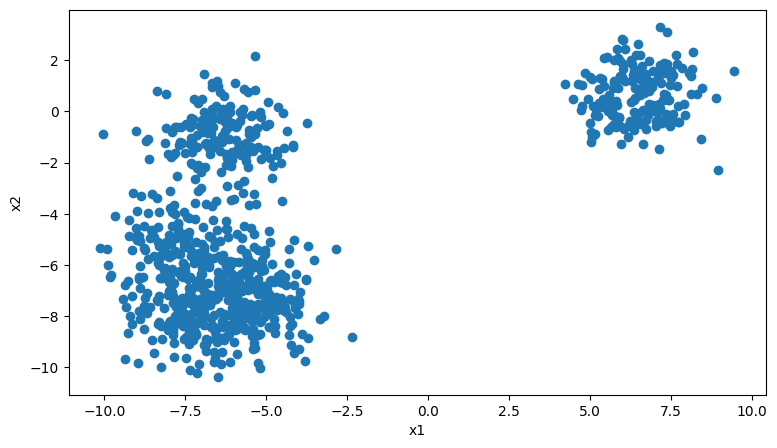

In [2]:
from sklearn.datasets import make_blobs

x,y = make_blobs(n_samples=900,centers=5,cluster_std=1)

plt.figure(figsize=(9,5))
plt.scatter(x[:,0],x[:,1])
plt.xlabel('x1')
plt.ylabel('x2')

In [3]:
from sklearn.model_selection import train_test_split


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [4]:
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=4)
k_predict = k_means.fit_predict(x_train)

You could assign the centroid to start previously;

In [5]:
centroids = np.array([])
k_means2 = KMeans(init=centroids)

### Inertia and Silhouette
Inertia measures how close one instance is of its cluster centroid in mean.it is influenced directly by the number of **K**;More k : decreases the distances between instances while Less k :increases the distances.

In other side,Silhouette coeficient computes the distance between clusters according the chose of **K**. 

In [6]:
from sklearn.metrics import silhouette_score

#inertia
print(k_means.score,k_means.inertia_)

#sil
print(f'Silhouette: {silhouette_score(x_train,k_means.labels_)}')

<bound method _BaseKMeans.score of KMeans(n_clusters=4)> 1711.7808661669078
Silhouette: 0.5137325905454359


We also have the **MiniBatchMeans**; support to online learning.The algorithm computes the centroid of clusters at each iteration and updates it using the parans:

- Batch_size
- Max_iter

In [7]:
from sklearn.cluster import MiniBatchKMeans

mb_means = MiniBatchKMeans(n_clusters=4)
mb_means.fit(x_train)

,n_clusters,4
,init,'k-means++'
,max_iter,100
,batch_size,1024
,verbose,0
,compute_labels,True
,random_state,None
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,'auto'


### Using K-Means for diferents purpouses
KMeans algorithm is a versatile model,which allow us use in diferents ways for find groups in our data.

#### 1.Image Segmentation
We can divide a image in mutiple segments according its groups of pixels.this tecnique has 2 forms:

1. Semantic Segmentation
2. Instance Segmentation



In [8]:
from matplotlib.image import imread
import os

image = imread('C:\\Users\\augusto\\Downloads\\duke-inferno-and-everflame-mansion-honkai-star-rail.webp')
image = image.astype(np.float32) / 255
image.shape



(575, 1024, 3)

In [9]:
print(image.min(), image.max())

0.0 1.0


In [10]:
x_image = image.reshape(-1,3)
k_means_image = KMeans(n_clusters=2).fit(x_image)

segmented_img = k_means_image.cluster_centers_[k_means_image.labels_]
segmented_img = segmented_img.reshape(image.shape)

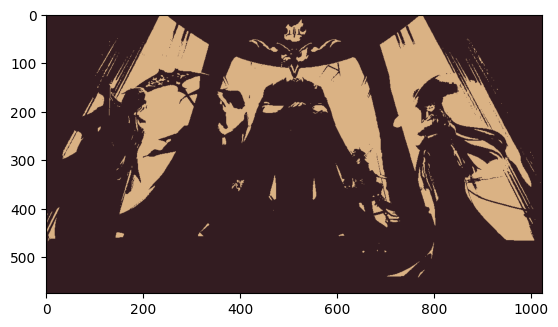

In [11]:
plt.imshow(segmented_img)
plt.show()

In [12]:
def k_images(n):
    
    
    for i in range(1,5):

        k_means_image = KMeans(n_clusters=i*n).fit(x_image)

        segmented_img = k_means_image.cluster_centers_[k_means_image.labels_]
        segmented_img = segmented_img.reshape(image.shape)

        plt.figure(figsize=(10, 10))
        plt.subplot(2, 2,i)
        plt.imshow(segmented_img)
        plt.title(f'n_clusters(colors): {i*n}')
        plt.show()



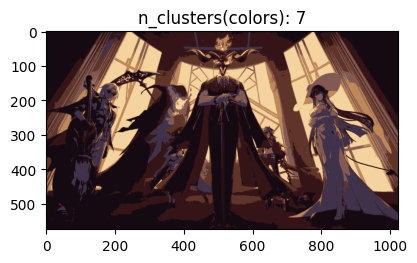

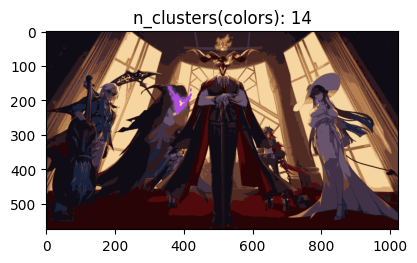

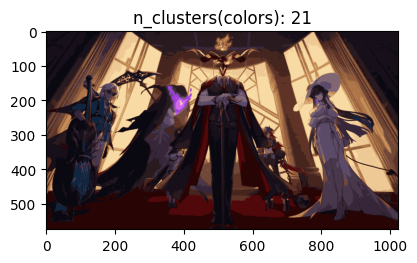

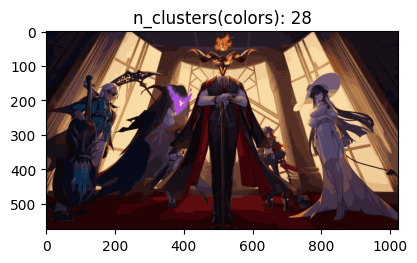

None


In [13]:

print(k_images(7))

#### 2.Preprocessing
Using clusters,we can reduce dimensionality of data before supervised training.in that way,the training becomes faster.

In [14]:
from sklearn.datasets import load_digits
from sklearn.pipeline import Pipeline

x_digits,y_digits = load_digits(return_X_y=True)

x_train_d,x_test_d,y_train_d,y_test_d = train_test_split(x_digits,y_digits)

In [15]:
from sklearn.linear_model import LogisticRegression

pipeline_k = Pipeline([
    ('k_means',KMeans(n_clusters=50)),
    ('log_reg',LogisticRegression())
])

model = LogisticRegression()

pipeline_k.fit(x_train_d,y_train_d)
model.fit(x_train_d,y_train_d)




c:\Users\augusto\.vscode\Data Sci and Ml\Linear_Regression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\augusto\.vscode\Data Sci and Ml\Linear_Regression\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown i

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
print(pipeline_k.score(x_test_d,y_test_d),model.score(x_test_d,y_test_d))

0.9577777777777777 0.9533333333333334


Then,you can use **GridSearch** for see how the model performs with diferents n of clusters.

#### 3.Semisupervised
We can also find clusters that corresponds better to one class.

In [17]:
Kmeans_semisupervised = KMeans(n_clusters=60)
x_digits_dist = Kmeans_semisupervised.fit_transform(x_train_d)
idx_digits = np.argmin(x_digits_dist,axis=0)
x_representative_digits = x_train_d[idx_digits]

Or label propagation:

In [18]:
def label_prop(k,model,train_set):
    y_train_d_prop = np.empty(len(x_train_d),dtype=np.int32)
    for i in range(k):
        y_train_d_prop[model.labels_ == i] = train_set[i]


We can label it to 20% most close instances

In [ ]:

def k_closest_instances(k,prop):
    x_cluster_digits = x_digits_dist[np.arrange(len(x_train_d)),Kmeans_semisupervised.labels_]
    #peforms in each cluster-label

    for i in range(k):
        in_cluster = (Kmeans_semisupervised.labels_ == i)
        cluster_dist = x_cluster_digits[in_cluster]
        cutoff_distance = np.percentile(cluster_dist,prop)
        above_cutoff = (x_cluster_digits > cutoff_distance)
        x_cluster_digits[in_cluster & above_cutoff] = -1

    partially_propagated = (x_cluster_digits != -1)
    x_digits_partially_propagated = x_train_d[partially_propagated]
    y_digits_partially_propagated = y_train_d[partially_propagated]


Here,we have find the n clusters for representative data labels.

DBScan